In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv
/kaggle/input/digit-recognizer/sample_submission.csv


In [2]:
import numpy as np
from keras import layers
from keras.layers import Dropout,Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
from keras.models import Model, load_model
from keras.preprocessing import image
from keras.utils import layer_utils
from keras.utils.data_utils import get_file
from keras.applications.imagenet_utils import preprocess_input
import pydot
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot
from keras.utils import plot_model
from keras.initializers import glorot_uniform
import scipy.misc
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
%matplotlib inline

import keras.backend as K
K.set_image_data_format('channels_last')
K.set_learning_phase(1)

In [3]:
# Importing data
train = pd.read_csv("../input/digit-recognizer/train.csv")
test = pd.read_csv("../input/digit-recognizer/test.csv")
sample = pd.read_csv("../input/digit-recognizer/sample_submission.csv")

In [4]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
sample.head()

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [7]:
print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


In [8]:
train_y = train.label
train_y.shape

(42000,)

In [9]:
train_x = train.drop(['label'],axis=1)
train_x.shape

(42000, 784)

In [10]:
#Normalization 
train_x = train_x/255
print(train_x.shape)
test_x = test/255
print(test_x.shape)

(42000, 784)
(28000, 784)


In [11]:
train_x.isnull().any().sum()

0

In [12]:
train_x = train_x.values.reshape(-1,28,28,1)
train_x.shape

(42000, 28, 28, 1)

In [13]:
test_x = test.values.reshape(-1,28,28,1)
test_x.shape

(28000, 28, 28, 1)

In [14]:
#Converting labels to one hot matrices
from keras.utils.np_utils import to_categorical
train_y = to_categorical(train_y,10)
train_y.shape

(42000, 10)

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline

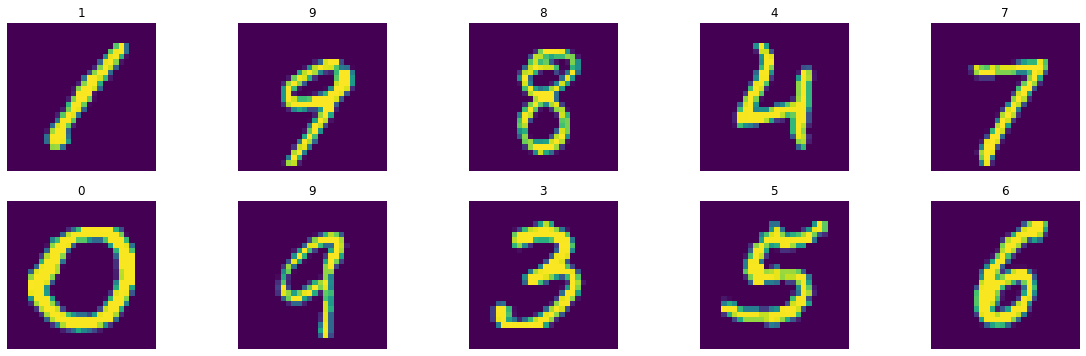

In [16]:
plt.figure(figsize=(20,6))

for i,j in enumerate([0,6999,13999,20999,27999,34999,41999,7999,36999,14999]):
    plt.subplot(2,5,i+1)
    plt.imshow(train_x[j].reshape(28,28))
    plt.title(np.argmax(train_y[j]))
    plt.axis("off")

In [17]:
#Let's split the data into train and test
from sklearn.model_selection import train_test_split
train_x, val_x, train_y, val_y = train_test_split(train_x,train_y,test_size=0.1,random_state=2)
print(train_x.shape)
print(train_y.shape)
print(val_x.shape)
print(val_y.shape)

(37800, 28, 28, 1)
(37800, 10)
(4200, 28, 28, 1)
(4200, 10)


In [18]:
#CNN Model

def modeln(input_shape = (28,28,1),classes=10):
    
    X_input = Input(input_shape)
    
    X = ZeroPadding2D((3,3))(X_input)
    
    X = Conv2D(filters = 32,kernel_size=(5,5),strides=(1,1),padding='same',kernel_initializer= glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((2,2))(X)
    
    X = Conv2D(filters=32, kernel_size=(5,5), strides=(1,1),padding='same',kernel_initializer= glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    
    X = Conv2D(filters=64, kernel_size=(3,3), strides=(1,1),padding='same',kernel_initializer= glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((2,2))(X)
  
    X = Conv2D(filters=64, kernel_size=(3,3), strides=(1,1),padding='same',kernel_initializer= glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    
    X = Flatten()(X)
    X = Dense(256, activation='relu')(X)
    X = Dense(128, activation='relu')(X)
    X = Dense(10, activation='softmax')(X)
    
    #create model
    model = Model(inputs = X_input, outputs=X)
    
    return model
    
    

In [19]:
model = modeln(input_shape=(28,28,1), classes=10)

In [20]:
model.compile(optimizer='adam', loss = 'categorical_crossentropy',metrics = ['accuracy'])

In [21]:
history = model.fit(train_x,train_y,epochs=5,batch_size=32,validation_data=(val_x,val_y))

Epoch 1/5
1182/1182 [==============================] - 6s 5ms/step - loss: 0.1323 - accuracy: 0.9590 - val_loss: 0.0801 - val_accuracy: 0.9776
Epoch 2/5
1182/1182 [==============================] - 6s 5ms/step - loss: 0.0560 - accuracy: 0.9818 - val_loss: 0.0660 - val_accuracy: 0.9819
Epoch 3/5
1182/1182 [==============================] - 5s 5ms/step - loss: 0.0435 - accuracy: 0.9865 - val_loss: 0.0428 - val_accuracy: 0.9895
Epoch 4/5
1182/1182 [==============================] - 5s 5ms/step - loss: 0.0317 - accuracy: 0.9904 - val_loss: 0.0494 - val_accuracy: 0.9869
Epoch 5/5
1182/1182 [==============================] - 5s 5ms/step - loss: 0.0288 - accuracy: 0.9914 - val_loss: 0.0476 - val_accuracy: 0.9862


In [22]:
print("loss: "+str(history.history["loss"]))
print("accuracy: "+str(history.history["accuracy"]))
print("val loss: "+str(history.history['val_loss']))
print("val accuracy"+str(history.history['val_accuracy']))

loss: [0.13226570188999176, 0.0559685155749321, 0.043548669666051865, 0.03169887140393257, 0.02878654934465885]
accuracy: [0.9589682817459106, 0.9818254113197327, 0.9865344166755676, 0.9903703927993774, 0.9913756847381592]
val loss: [0.08014610409736633, 0.06603049486875534, 0.042770955711603165, 0.04943626746535301, 0.047646839171648026]
val accuracy[0.9776190519332886, 0.9819047451019287, 0.9895238280296326, 0.9869047403335571, 0.9861904978752136]


In [23]:
#Let's do data augmentation and check accuracy. In order to avoid over-fitting we do data augmentation.
from keras.preprocessing.image import ImageDataGenerator
data_augmentation = ImageDataGenerator(featurewise_center=False, samplewise_center=False,
    featurewise_std_normalization=False, samplewise_std_normalization=False,
    zca_whitening=False, zca_epsilon=1e-06, rotation_range=0.1, width_shift_range=0.2,
    height_shift_range=0.1, brightness_range=None, shear_range=0.0, zoom_range=0.1,
    channel_shift_range=0.0, fill_mode='nearest', cval=0.0, horizontal_flip=False,
    vertical_flip=False, rescale=None, preprocessing_function=None,
    data_format=None, validation_split=0.0, dtype=None)

In [24]:
data_augmentation.fit(train_x)

In [25]:
model.fit(data_augmentation.flow(train_x,train_y,batch_size=32),epochs=5,validation_data=(val_x,val_y))

Epoch 1/5
1182/1182 [==============================] - 15s 13ms/step - loss: 0.0904 - accuracy: 0.9734 - val_loss: 0.0360 - val_accuracy: 0.9905
Epoch 2/5
1182/1182 [==============================] - 17s 14ms/step - loss: 0.0506 - accuracy: 0.9848 - val_loss: 0.0744 - val_accuracy: 0.9776
Epoch 3/5
1182/1182 [==============================] - 16s 13ms/step - loss: 0.0448 - accuracy: 0.9860 - val_loss: 0.0502 - val_accuracy: 0.9831
Epoch 4/5
1182/1182 [==============================] - 16s 14ms/step - loss: 0.0401 - accuracy: 0.9878 - val_loss: 0.0596 - val_accuracy: 0.9831
Epoch 5/5
1182/1182 [==============================] - 16s 13ms/step - loss: 0.0351 - accuracy: 0.9902 - val_loss: 0.0279 - val_accuracy: 0.9907


In [26]:
result = model.predict(test_x)
result = np.argmax(result, axis=1)
result = pd.Series(result,name = 'Label')
result

0        2
1        0
2        8
3        0
4        3
        ..
27995    9
27996    7
27997    3
27998    9
27999    2
Name: Label, Length: 28000, dtype: int64

#### After Data Augmentation accuracy improves

In [27]:
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),result],axis = 1)
submission.to_csv("Submission.csv",index=False)